# 01 · image2vienna: from a trade mark image to Vienna codes

This notebook shows the public interface of `image2vienna` on two drawn logos and
evaluates it on 300 EUIPO marks with the examiners' codes.

Prerequisites, run once from the repository root:

```bash
uv sync --all-extras
uv run i2vienna build --edition 10                 # WIPO XML -> scheme table + index
uv run i2vienna l3d --n 300                        # eval cases (section 7)
uv run i2vienna describe-cases evals/l3d_300.jsonl # the vision model over the cases, cached
```

Everything below reads the Parquet tables under `data/` (or `$IMAGE2VIENNA_HOME`).

In [1]:
import tempfile
from pathlib import Path

import pandas as pd
from IPython.display import Image as Show
from IPython.display import display

from image2vienna import ViennaClassifier

ROOT = Path.cwd() if (Path.cwd() / "evals").is_dir() else Path.cwd().parent
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", None)


def as_frame(matches):
    # One row per match; `path` is the full text the entry was embedded with
    # (category > division > section), which is also the explanation.
    return pd.DataFrame(
        [
            {
                "code": ("A " if m.auxiliary else "") + m.pretty,
                "level": m.level,
                "score": round(m.score, 3),
                "path": m.text,
            }
            for m in matches
        ]
    )

## 1. One classifier, one index

A `ViennaClassifier` is bound to an edition, a scheme language, an embedding model
and a vision model (Florence-2 base by default, 230M parameters, through
transformers on CPU or GPU). Loading is lazy: the index (1,955 vectors, 7.7 MB), the
embedder and the vision model load on first use. Every entry was embedded from its
full path of titles, never from its own title alone.

In [2]:
clf = ViennaClassifier("10")
print("edition", clf.edition, "|", clf.index.meta.model, "|", len(clf.index), "entries")
print(clf.index.text_of("1.1.2"))
print(clf.index.text_of("24.9.9"))

edition 10 | st:intfloat/multilingual-e5-base | 1955 entries
Celestial bodies, natural phenomena, geographical maps > Stars, comets > One star
Heraldry, coins, emblems, symbols > Crowns, diadems > Crowns having three triangular points


## 2. Two drawn logos

The examples are drawn with Pillow so the notebook runs without any image file:
three stars above a crescent moon, and the letters "AB" on a shield under a crown.

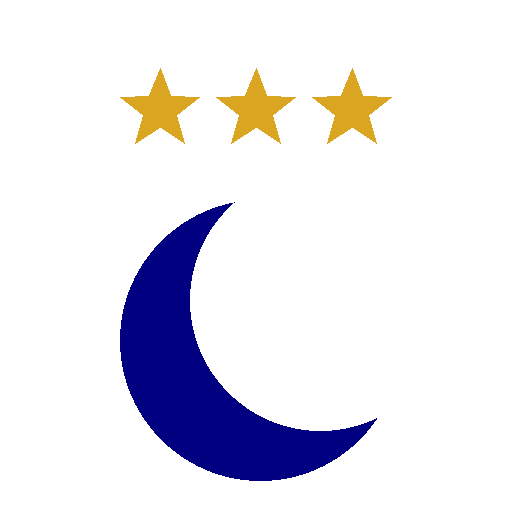

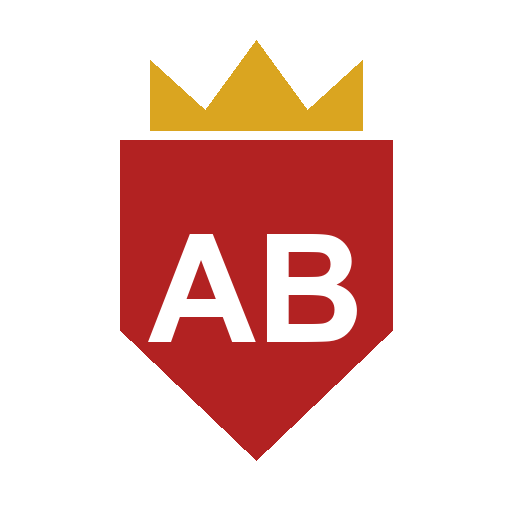

In [3]:
import math

from PIL import Image, ImageDraw, ImageFont

W = 512
work = Path(tempfile.mkdtemp())


def star(d, cx, cy, r, fill):
    pts = []
    for i in range(10):
        a = -math.pi / 2 + i * math.pi / 5
        rr = r if i % 2 == 0 else r * 0.42
        pts.append((cx + rr * math.cos(a), cy + rr * math.sin(a)))
    d.polygon(pts, fill=fill)


im = Image.new("RGB", (W, W), "white")
d = ImageDraw.Draw(im)
d.ellipse((120, 200, 400, 480), fill="navy")
d.ellipse((190, 170, 450, 430), fill="white")
for cx in (160, 256, 352):
    star(d, cx, 110, 42, "goldenrod")
stars_moon = work / "stars_moon.png"
im.save(stars_moon)

im = Image.new("RGB", (W, W), "white")
d = ImageDraw.Draw(im)
d.polygon([(120, 140), (392, 140), (392, 330), (256, 460), (120, 330)], fill="firebrick")
d.polygon(
    [(150, 130), (150, 60), (205, 110), (256, 40), (307, 110), (362, 60), (362, 130)],
    fill="goldenrod",
)
try:
    font = ImageFont.truetype("/System/Library/Fonts/Supplemental/Arial Bold.ttf", 150)
except OSError:
    font = ImageFont.load_default()
d.text((256, 290), "AB", fill="white", font=font, anchor="mm")
shield = work / "shield_crown_ab.png"
im.save(shield)

display(Show(filename=str(stars_moon), width=200), Show(filename=str(shield), width=200))

## 3. Stage one: what the vision model sees

`describe` runs Florence-2's detailed-caption task on the image: a few sentences
naming the objects, letters and colours literally (repeated sentences, which small
models produce, are dropped). The prose is the query of the next stage.

In [4]:
for image in (stars_moon, shield):
    print(image.name)
    print(clf.describe(image))
    print()

stars_moon.png


/Users/jaimenms/code/personal/study-image-to-vienna/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/665 [00:00<?, ?it/s]

Loading weights:  22%|██▏       | 145/665 [00:00<00:00, 1439.17it/s]

Loading weights:  43%|████▎     | 289/665 [00:00<00:00, 675.88it/s] 

Loading weights: 100%|██████████| 665/665 [00:00<00:00, 1657.04it/s]

A simple simple image of a crescent moon with four stars above it. The background is white. The stars are yellow. The crescent is blue. The image is a simple and simple design.

shield_crown_ab.png


A logo is shown. The logo is red and has white letters on it. The letters are A and B. The background of the logo is white. At the top of the crest is a yellow crown.



## 4. Stage two: ranked codes

`classify` runs both stages. `level` picks the answer's level (`category`,
`division`, `section`, or `auto` for as deep as the evidence supports); the `A`
before a code marks an auxiliary section, which offices code without the letter
(`m.padded` prints the EUIPO form `01.01.04`). Results on the same branch as a
better-ranked one are dropped, so each row is a distinct branch.

In [5]:
as_frame(clf.classify(stars_moon, level="section", top_k=5))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 65572.04it/s]

,code,level,score,path
0,29.1.14,section,0.831,Colours > Colours > Four colours
1,A 1.1.9,section,0.827,"Celestial bodies, natural phenomena, geographical maps > Stars, comets > Stars with four points"
2,29.1.15,section,0.826,Colours > Colours > Five colours and over
3,A 1.1.10,section,0.823,"Celestial bodies, natural phenomena, geographical maps > Stars, comets > Stars with more than four points"
4,1.7.19,section,0.822,"Celestial bodies, natural phenomena, geographical maps > Moon > Several crescents or half-moons"


In [6]:
as_frame(clf.classify(shield, level="division", top_k=5))

,code,level,score,path
0,24.9,division,0.805,"Heraldry, coins, emblems, symbols > Crowns, diadems"
1,24.7,division,0.803,"Heraldry, coins, emblems, symbols > Flags"
2,24.13,division,0.802,"Heraldry, coins, emblems, symbols > Crosses"
3,24.15,division,0.800,"Heraldry, coins, emblems, symbols > Arrows"
4,24.11,division,0.799,"Heraldry, coins, emblems, symbols > Emblems, insignia"


In [7]:
as_frame(clf.classify(shield, level="auto", top_k=5))

,code,level,score,path
0,24.9.2,section,0.812,"Heraldry, coins, emblems, symbols > Crowns, diadems > Crowns open at the top"
1,29.1.2,section,0.811,"Colours > Colours > Yellow, gold"
2,24.13.25,section,0.804,"Heraldry, coins, emblems, symbols > Crosses > Other crosses"
3,24.11.11,section,0.803,"Heraldry, coins, emblems, symbols > Emblems, insignia > Globes surmounted by a cross"
4,24.7,division,0.803,"Heraldry, coins, emblems, symbols > Flags"


## 5. A description as the query

`classify_text` runs the cheap stage alone, so a cached or hand-edited description
costs milliseconds and a sentence written by hand is a valid input. `chunking="max"`
embeds each sentence separately and scores an entry by its best sentence, one code
per element; `exclude_codes` masks a subtree, here the Colours category, which every
description mentions.

In [8]:
text = (
    "A roaring lion's head seen from the front, with a mane. "
    "Two crossed swords below it. Red and gold."
)
as_frame(
    clf.classify_text(text, level="section", top_k=5, chunking="max", exclude_codes=("29",))
)

,code,level,score,path
0,A 24.5.21,section,0.831,"Heraldry, coins, emblems, symbols > Medals, coins, decorations, orders > Golden fleece"
1,A 14.7.3,section,0.830,"Ironmongery, tools, ladders > Tools > Two hammers, two sledge-hammers or two axes, crossed"
2,24.13.25,section,0.817,"Heraldry, coins, emblems, symbols > Crosses > Other crosses"
3,24.15.2,section,0.816,"Heraldry, coins, emblems, symbols > Arrows > Two arrows, double-headed arrows"
4,A 24.13.17,section,0.811,"Heraldry, coins, emblems, symbols > Crosses > Crosses containing a figurative element"


## 6. Reading an entry

The scheme table keeps each entry's code path, its explanatory notes and, for an
auxiliary section, the principal sections it is associated with. The embedded text
is the chain of titles; the notes are an opt-in text style (`--notes`).

In [9]:
scheme = clf.index.scheme
for code_ in ("2.1.4", "1.1.4"):
    node = scheme.node(code_)
    print(("A " if node.auxiliary else "") + code_, "|", " > ".join(scheme.path_of(code_)))
    print("  text:", scheme.text_of(code_))
    print("  with notes:", scheme.text_of(code_, notes=True))
    if node.associated:
        print("  associated with principal sections", ", ".join(node.associated))
    print()

2.1.4 | 2 > 2.1 > 2.1.4
  text: Human beings > Men > Men wearing either their traditional clothing, or a folk or historical costume
  with notes: Human beings > Men > Men wearing either their traditional clothing, or a folk or historical costume. Including, for example, cowboys, native Americans, indigenous men, wearing their traditional clothing.

A 1.1.4 | 1 > 1.1 > 1.1.4
  text: Celestial bodies, natural phenomena, geographical maps > Stars, comets > Three stars
  with notes: Celestial bodies, natural phenomena, geographical maps > Stars, comets > Three stars
  associated with principal sections 1.1.1, 1.1.15



## 7. Evaluation on 300 EUIPO marks

`evals/l3d_300.jsonl` holds 300 figurative EU trade marks from the Large Labelled
Logo Dataset (EUIPO open data, 1996 to 2020) with the codes EUIPO examiners
assigned, and the descriptions written by every vision model tried: Florence-2 (the
default), Qwen2.5-VL 7B through Ollama (two prompts) and SmolVLM (rejected). The
eval re-scores those cached descriptions, so it runs in seconds. A gold code
shallower than a level does not count at that level; about a fifth of the gold codes
are EUIPO extension codes that no WIPO edition contains, which caps the section
level.

In [10]:
from image2vienna.eval import evaluate, load_cases

cases = load_cases(ROOT / "evals" / "l3d_300.jsonl")
rows = []
for key in sorted({k for c in cases for k in c.descriptions}):
    subset = [c for c in cases if key in c.descriptions]
    for chunking in ("whole", "mean"):
        result = evaluate(
            subset,
            lambda c, k=key, ch=chunking: clf.classify_text(
                c.descriptions[k], level="section", top_k=10, chunking=ch
            ),
            level="section",
            top_k=10,
        )
        for r in result.rows(ks=(1, 3, 10)):
            rows.append({"descriptions": key, "chunking": chunking, **r})
table = pd.DataFrame(rows)
percent = {c: "{:.1%}" for c in table.columns if c.startswith(("hit", "recall", "main"))}
table.style.format(percent | {"mrr": "{:.3f}"})

,descriptions,chunking,level,n,hit@1,hit@3,hit@10,recall@3,recall@10,main@1,mrr
0,hf:HuggingFaceTB/SmolVLM-256M-Instruct|inventory,whole,category,300,20.3%,42.3%,47.3%,29.1%,32.2%,11.0%,0.314
1,hf:HuggingFaceTB/SmolVLM-256M-Instruct|inventory,whole,division,300,14.3%,25.7%,31.0%,16.4%,19.8%,8.0%,0.207
2,hf:HuggingFaceTB/SmolVLM-256M-Instruct|inventory,whole,section,297,5.7%,10.8%,15.5%,4.5%,7.2%,1.7%,0.086
3,hf:HuggingFaceTB/SmolVLM-256M-Instruct|inventory,mean,category,300,20.3%,42.0%,46.7%,28.9%,31.7%,11.0%,0.312
4,hf:HuggingFaceTB/SmolVLM-256M-Instruct|inventory,mean,division,300,14.3%,25.3%,30.3%,16.3%,19.4%,8.0%,0.205
5,hf:HuggingFaceTB/SmolVLM-256M-Instruct|inventory,mean,section,297,5.7%,10.8%,15.8%,4.5%,7.4%,1.7%,0.087
6,hf:HuggingFaceTB/SmolVLM-256M-Instruct|light,whole,category,300,29.7%,49.3%,50.3%,31.7%,32.6%,16.7%,0.394
7,hf:HuggingFaceTB/SmolVLM-256M-Instruct|light,whole,division,300,12.7%,24.3%,30.0%,13.4%,16.9%,6.0%,0.188
8,hf:HuggingFaceTB/SmolVLM-256M-Instruct|light,whole,section,297,3.7%,6.4%,14.1%,3.2%,5.9%,2.0%,0.063
9,hf:HuggingFaceTB/SmolVLM-256M-Instruct|light,mean,category,300,23.0%,41.7%,43.7%,27.1%,29.4%,13.0%,0.321


Florence-2's captions score within a few points of the 7B model's inventories at a
thirtieth of the size, which is why it is the only default. The frequency baseline
(always answer the most frequent codes of the 770k L3D labels), the per-category
breakdown and every rejected variant are in `PERFORMANCE.md` and `docs/evals.md`;
`scripts/eval_sweep.py` prints them from the same cached descriptions.